In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Obesity_Quantum_Project/data/ObesityDataSet_raw_and_data_sinthetic.csv"
df = pd.read_csv(file_path)

print("Veri seti boyutu:", df.shape)
df.head()

Veri seti boyutu: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
print(df.columns.tolist())

['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [ ]:
df.shape

(2111, 17)

In [ ]:
df.columns.tolist()

['Gender',
 'Age',
 'Height',
 'Weight',
 'family_history_with_overweight',
 'FAVC',
 'FCVC',
 'NCP',
 'CAEC',
 'SMOKE',
 'CH2O',
 'SCC',
 'FAF',
 'TUE',
 'CALC',
 'MTRANS',
 'NObeyesdad']

In [ ]:
df['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [ ]:
df['NObeyesdad'].value_counts(normalize=True) * 100

,proportion
NObeyesdad,
Obesity_Type_I,16.627191
Obesity_Type_III,15.348176
Obesity_Type_II,14.069162
Overweight_Level_I,13.737565
Overweight_Level_II,13.737565
Normal_Weight,13.595452
Insufficient_Weight,12.884889


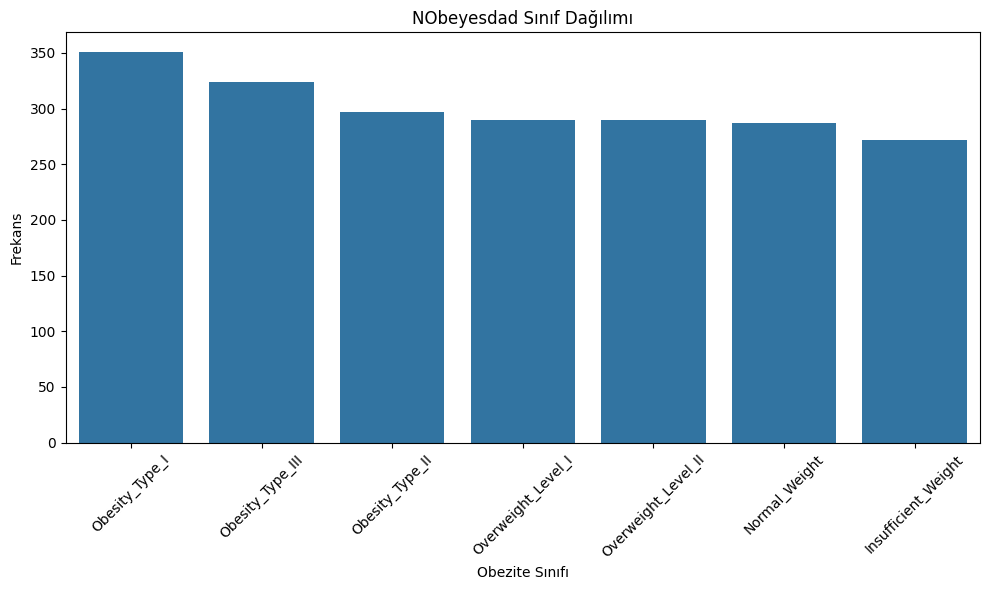

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title('NObeyesdad Sınıf Dağılımı')
plt.xlabel('Obezite Sınıfı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

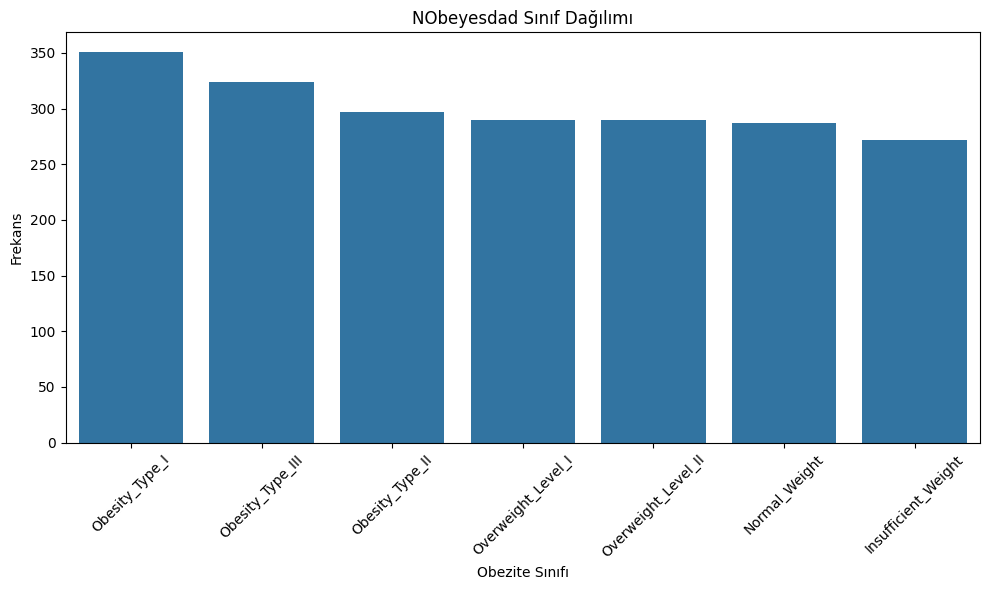

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title('NObeyesdad Sınıf Dağılımı')
plt.xlabel('Obezite Sınıfı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/class_distribution.png', dpi=300)
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Sayısal sütunlar:", numerical_cols)
print("Kategorik sütunlar:", categorical_cols)

Sayısal sütunlar: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Kategorik sütunlar: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


In [ ]:
target_col = 'NObeyesdad'
feature_cols = [col for col in df.columns if col != target_col]

numerical_features = [col for col in numerical_cols if col != target_col]
categorical_features = [col for col in categorical_cols if col != target_col]

print("Hedef:", target_col)
print("Sayısal özellikler:", numerical_features)
print("Kategorik özellikler:", categorical_features)

Hedef: NObeyesdad
Sayısal özellikler: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Kategorik özellikler: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [ ]:
for col in categorical_features + [target_col]:
    print(f"\nSütun: {col}")
    print(df[col].value_counts())


Sütun: Gender
Gender
Male      1068
Female    1043
Name: count, dtype: int64

Sütun: family_history_with_overweight
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

Sütun: FAVC
FAVC
yes    1866
no      245
Name: count, dtype: int64

Sütun: CAEC
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

Sütun: SMOKE
SMOKE
no     2067
yes      44
Name: count, dtype: int64

Sütun: SCC
SCC
no     2015
yes      96
Name: count, dtype: int64

Sütun: CALC
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

Sütun: MTRANS
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

Sütun: NObeyesdad
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II   

In [ ]:
print("Temizleme öncesi boyut:", df.shape)

df = df.drop_duplicates()

print("Temizleme sonrası boyut:", df.shape)
print("Kalan duplicate sayısı:", df.duplicated().sum())

Temizleme öncesi boyut: (2111, 17)
Temizleme sonrası boyut: (2087, 17)
Kalan duplicate sayısı: 0


In [ ]:
target_col = 'NObeyesdad'

X = df.drop(columns=[target_col])
y = df[target_col]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (2087, 16)
y boyutu: (2087,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train boyutu:", X_train.shape)
print("X_test boyutu:", X_test.shape)
print("y_train boyutu:", y_train.shape)
print("y_test boyutu:", y_test.shape)

X_train boyutu: (1669, 16)
X_test boyutu: (418, 16)
y_train boyutu: (1669,)
y_test boyutu: (418,)


In [ ]:
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

print("Sayısal özellik sayısı:", len(numerical_features))
print("Kategorik özellik sayısı:", len(categorical_features))

Sayısal özellik sayısı: 8
Kategorik özellik sayısı: 8


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Height', 'Weight', 'FCVC', 'NCP',
                                  'CH2O', 'FAF', 'TUE']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'family_history_with_overweight',
                                  'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
                                  'MTRANS'])])


In [ ]:
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

print("Sayısal özellik sayısı:", len(numerical_features))
print("Kategorik özellik sayısı:", len(categorical_features))

Sayısal özellik sayısı: 8
Kategorik özellik sayısı: 8


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Height', 'Weight', 'FCVC', 'NCP',
                                  'CH2O', 'FAF', 'TUE']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'family_history_with_overweight',
                                  'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
                                  'MTRANS'])])


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

print(logreg_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [ ]:
logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression modeli eğitildi.")

Logistic Regression modeli eğitildi.


In [ ]:
y_pred_logreg = logreg_pipeline.predict(X_test)

print("İlk 10 tahmin:")
print(y_pred_logreg[:10])

İlk 10 tahmin:
['Overweight_Level_II' 'Obesity_Type_II' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_II' 'Obesity_Type_II']


In [ ]:
from sklearn.metrics import accuracy_score

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", logreg_accuracy)

Logistic Regression Accuracy: 0.8971291866028708


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logreg))

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.84      0.82      0.83        57
     Obesity_Type_I       0.92      0.93      0.92        70
    Obesity_Type_II       0.94      1.00      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.80      0.80      0.80        55
Overweight_Level_II       0.82      0.72      0.77        58

           accuracy                           0.90       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.89      0.90      0.90       418



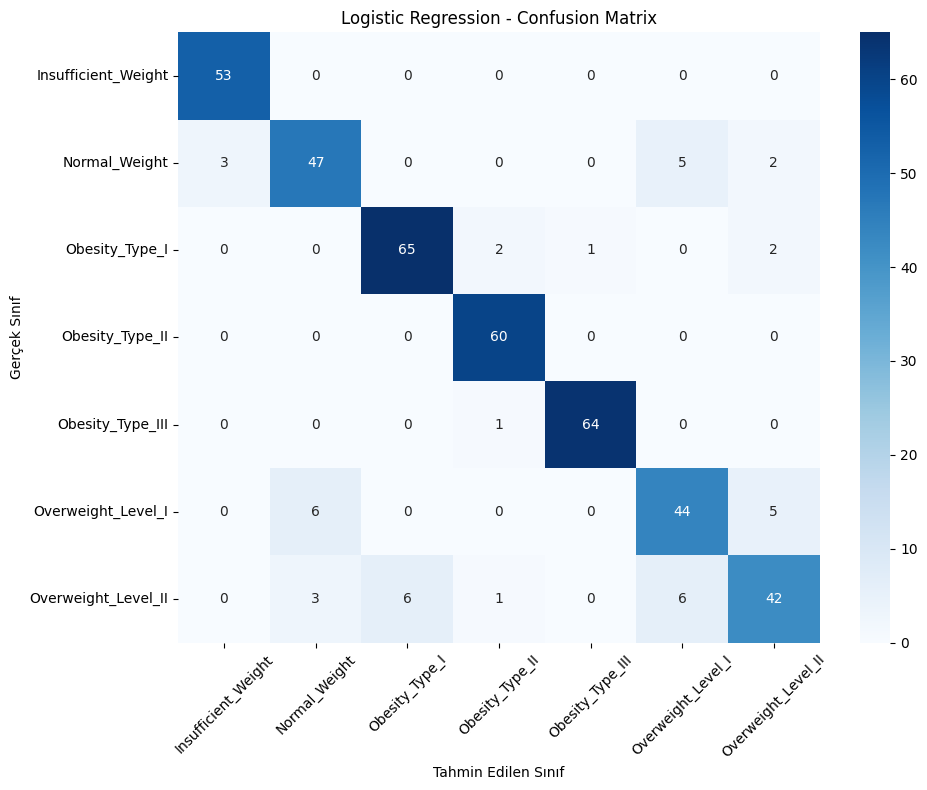

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred_logreg, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

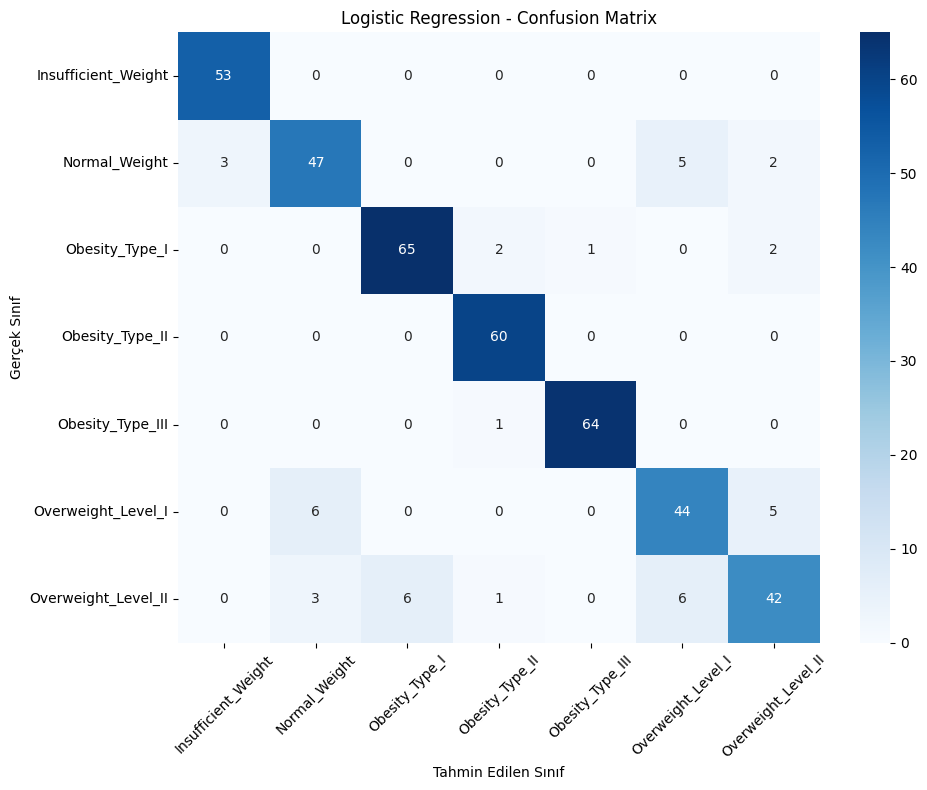

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/logreg_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [ ]:
rf_pipeline.fit(X_train, y_train)
print("Random Forest modeli eğitildi.")

Random Forest modeli eğitildi.


In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)

print("İlk 10 Random Forest tahmini:")
print(y_pred_rf[:10])

İlk 10 Random Forest tahmini:
['Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_II']


In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9449760765550239


In [ ]:
print(classification_report(y_test, y_pred_rf))

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.79      0.93      0.85        57
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.87      0.89        55
Overweight_Level_II       0.95      0.91      0.93        58

           accuracy                           0.94       418
          macro avg       0.95      0.94      0.94       418
       weighted avg       0.95      0.94      0.95       418



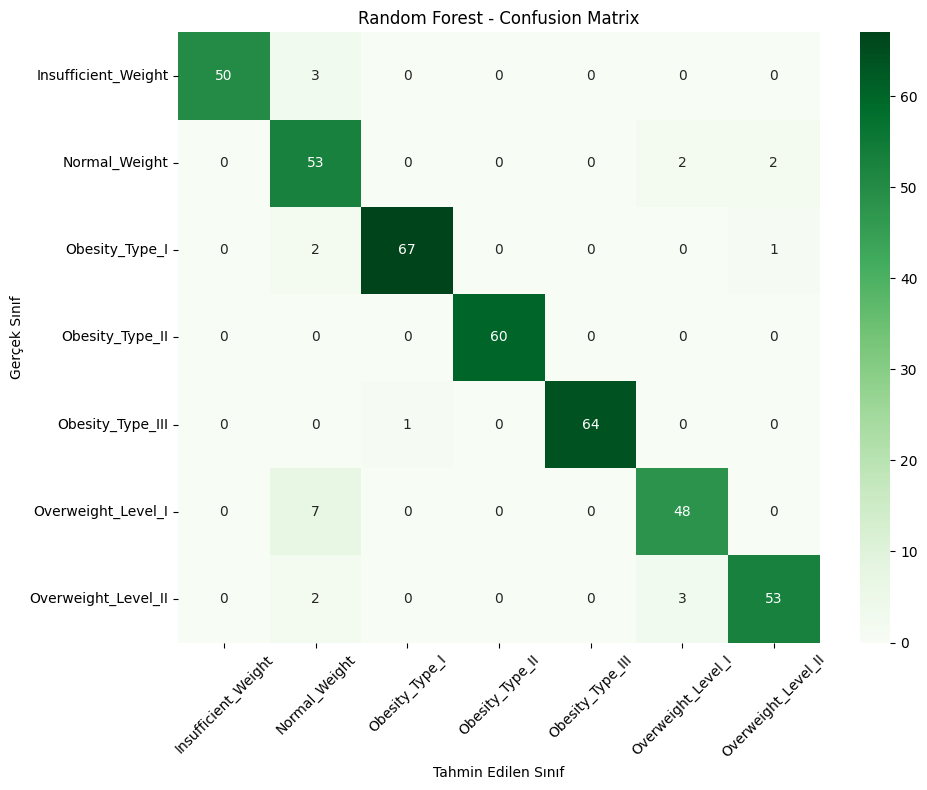

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Pipeline içinden trained model ve preprocessor'ı al
rf_model = rf_pipeline.named_steps['model']
rf_preprocessor = rf_pipeline.named_steps['preprocessor']

# One-hot sonrası tüm özellik adlarını al
feature_names = rf_preprocessor.get_feature_names_out()

# Önem skorlarını al
importances = rf_model.feature_importances_

print("Toplam dönüştürülmüş özellik sayısı:", len(feature_names))
print("Toplam importance sayısı:", len(importances))

Toplam dönüştürülmüş özellik sayısı: 31
Toplam importance sayısı: 31


In [ ]:
import pandas as pd

feat_imp_df = pd.DataFrame({
    'Özellik': feature_names,
    'Önem': importances
}).sort_values(by='Önem', ascending=False)

feat_imp_df.head(20)

,Özellik,Önem
2,num__Weight,0.281928
0,num__Age,0.092235
3,num__FCVC,0.082547
1,num__Height,0.079211
4,num__NCP,0.051313
6,num__FAF,0.046299
7,num__TUE,0.045342
5,num__CH2O,0.043819
8,cat__Gender_Female,0.036017
9,cat__Gender_Male,0.034566


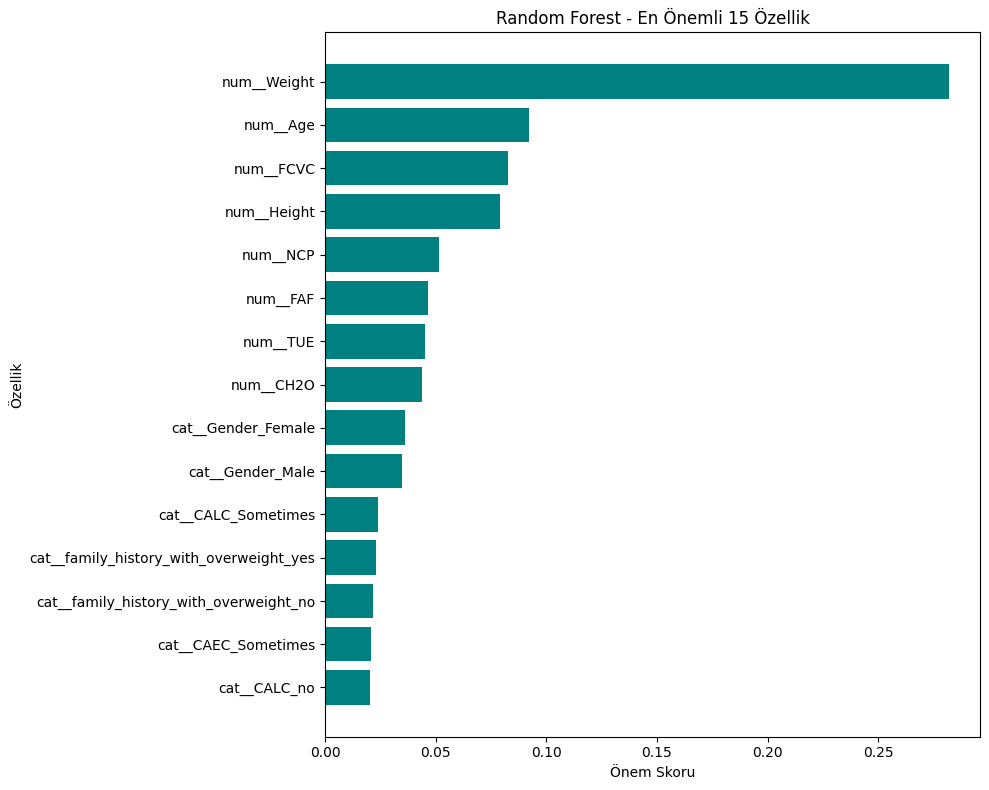

In [ ]:
plt.figure(figsize=(10, 8))
top_n = 15
top_features = feat_imp_df.head(top_n).sort_values(by='Önem', ascending=True)

plt.barh(top_features['Özellik'], top_features['Önem'], color='teal')
plt.xlabel("Önem Skoru")
plt.ylabel("Özellik")
plt.title("Random Forest - En Önemli 15 Özellik")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/rf_feature_importance_top15.png', dpi=300)
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [logreg_accuracy, rf_accuracy]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.897129
1,Random Forest,0.944976


In [ ]:
comparison_df.to_csv('/content/drive/MyDrive/Obesity_Quantum_Project/tables/model_comparison_initial.csv', index=False)

In [ ]:
from sklearn.metrics import f1_score

logreg_macro_f1 = f1_score(y_test, y_pred_logreg, average='macro')
logreg_weighted_f1 = f1_score(y_test, y_pred_logreg, average='weighted')

rf_macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average='weighted')

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [logreg_accuracy, rf_accuracy],
    'Macro F1': [logreg_macro_f1, rf_macro_f1],
    'Weighted F1': [logreg_weighted_f1, rf_weighted_f1]
})

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.897129,0.892760,0.895354
1,Random Forest,0.944976,0.943956,0.946096


In [ ]:
comparison_df.to_csv('/content/drive/MyDrive/Obesity_Quantum_Project/tables/model_comparison_with_f1.csv', index=False)
print("Genişletilmiş model karşılaştırma tablosu kaydedildi.")

Genişletilmiş model karşılaştırma tablosu kaydedildi.


In [ ]:
comparison_df_rounded = comparison_df.copy()
comparison_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']] = comparison_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']].round(4)

comparison_df_rounded

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.8971,0.8928,0.8954
1,Random Forest,0.9450,0.9440,0.9461


In [ ]:
comparison_df_rounded.to_csv('/content/drive/MyDrive/Obesity_Quantum_Project/tables/model_comparison_with_f1_rounded.csv', index=False)

In [ ]:
original_feature_importance = {}

for feat_name, importance in zip(feature_names, importances):
    if feat_name.startswith('num__'):
        original_name = feat_name.replace('num__', '')
    elif feat_name.startswith('cat__'):
        original_part = feat_name.replace('cat__', '')
        original_name = original_part.split('_')[0]
    else:
        original_name = feat_name

    if original_name in original_feature_importance:
        original_feature_importance[original_name] += importance
    else:
        original_feature_importance[original_name] = importance

original_feat_imp_df = pd.DataFrame({
    'Özellik': list(original_feature_importance.keys()),
    'Toplam_Önem': list(original_feature_importance.values())
}).sort_values(by='Toplam_Önem', ascending=False)

original_feat_imp_df

,Özellik,Toplam_Önem
2,Weight,0.281928
0,Age,0.092235
3,FCVC,0.082547
1,Height,0.079211
8,Gender,0.070583
4,NCP,0.051313
14,CALC,0.048864
6,FAF,0.046299
7,TUE,0.045342
9,family,0.044481


In [ ]:
original_feature_importance = {}

for feat_name, importance in zip(feature_names, importances):
    if feat_name.startswith('num__'):
        original_name = feat_name.replace('num__', '')

    elif feat_name.startswith('cat__'):
        cat_feature = feat_name.replace('cat__', '')

        matched_feature = None
        for col in categorical_features:
            if cat_feature.startswith(col + '_') or cat_feature == col:
                matched_feature = col
                break

        original_name = matched_feature if matched_feature is not None else cat_feature

    else:
        original_name = feat_name

    if original_name in original_feature_importance:
        original_feature_importance[original_name] += importance
    else:
        original_feature_importance[original_name] = importance

original_feat_imp_df = pd.DataFrame({
    'Özellik': list(original_feature_importance.keys()),
    'Toplam_Önem': list(original_feature_importance.values())
}).sort_values(by='Toplam_Önem', ascending=False)

original_feat_imp_df

,Özellik,Toplam_Önem
2,Weight,0.281928
0,Age,0.092235
3,FCVC,0.082547
1,Height,0.079211
8,Gender,0.070583
4,NCP,0.051313
14,CALC,0.048864
6,FAF,0.046299
7,TUE,0.045342
9,family_history_with_overweight,0.044481


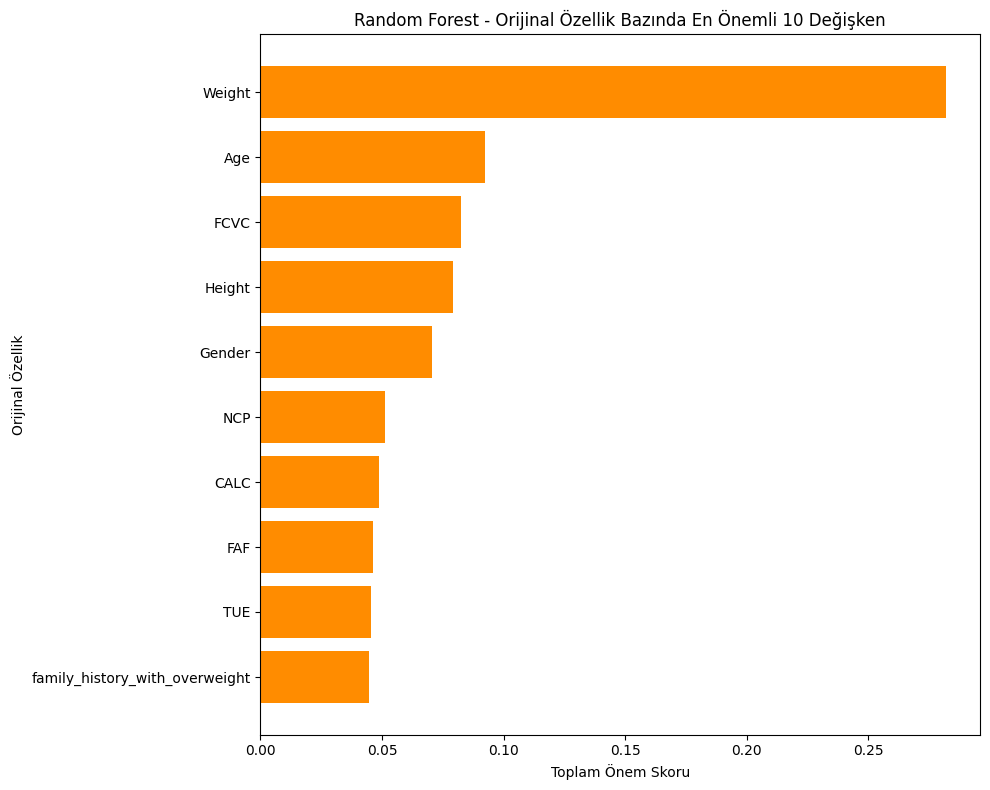

In [ ]:
plt.figure(figsize=(10, 8))
top_n = 10
top_original_features = original_feat_imp_df.head(top_n).sort_values(by='Toplam_Önem', ascending=True)

plt.barh(top_original_features['Özellik'], top_original_features['Toplam_Önem'], color='darkorange')
plt.xlabel("Toplam Önem Skoru")
plt.ylabel("Orijinal Özellik")
plt.title("Random Forest - Orijinal Özellik Bazında En Önemli 10 Değişken")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/rf_original_feature_importance_top10.png', dpi=300)
plt.show()

In [ ]:
original_feat_imp_df.to_csv('/content/drive/MyDrive/Obesity_Quantum_Project/tables/original_feature_importance.csv', index=False)
print("Orijinal özellik bazında importance tablosu kaydedildi.")

Orijinal özellik bazında importance tablosu kaydedildi.


In [ ]:
top10_features = [
    'Weight',
    'Age',
    'FCVC',
    'Height',
    'Gender',
    'NCP',
    'CALC',
    'FAF',
    'TUE',
    'family_history_with_overweight'
]

print("Seçilen top-10 özellikler:")
for i, feat in enumerate(top10_features, 1):
    print(f"{i}. {feat}")

Seçilen top-10 özellikler:
1. Weight
2. Age
3. FCVC
4. Height
5. Gender
6. NCP
7. CALC
8. FAF
9. TUE
10. family_history_with_overweight


In [ ]:
X_top10 = df[top10_features]
y_top10 = df['NObeyesdad']

print("X_top10 boyutu:", X_top10.shape)
print("y_top10 boyutu:", y_top10.shape)

X_top10 boyutu: (2087, 10)
y_top10 boyutu: (2087,)


In [ ]:
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(
    X_top10, y_top10,
    test_size=0.20,
    random_state=42,
    stratify=y_top10
)

print("X_train_10 boyutu:", X_train_10.shape)
print("X_test_10 boyutu:", X_test_10.shape)
print("y_train_10 boyutu:", y_train_10.shape)
print("y_test_10 boyutu:", y_test_10.shape)

X_train_10 boyutu: (1669, 10)
X_test_10 boyutu: (418, 10)
y_train_10 boyutu: (1669,)
y_test_10 boyutu: (418,)


In [ ]:
numerical_features_10 = ['Weight', 'Age', 'FCVC', 'Height', 'NCP', 'FAF', 'TUE']
categorical_features_10 = ['Gender', 'CALC', 'family_history_with_overweight']

print("Top-10 sayısal:", numerical_features_10)
print("Top-10 kategorik:", categorical_features_10)

Top-10 sayısal: ['Weight', 'Age', 'FCVC', 'Height', 'NCP', 'FAF', 'TUE']
Top-10 kategorik: ['Gender', 'CALC', 'family_history_with_overweight']


In [ ]:
preprocessor_10 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_10),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_10)
    ]
)

print(preprocessor_10)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Weight', 'Age', 'FCVC', 'Height', 'NCP',
                                  'FAF', 'TUE']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'CALC',
                                  'family_history_with_overweight'])])


In [ ]:
logreg_pipeline_10 = Pipeline([
    ('preprocessor', preprocessor_10),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

print(logreg_pipeline_10)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Weight', 'Age', 'FCVC',
                                                   'Height', 'NCP', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'CALC',
                                                   'family_history_with_overweight'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [ ]:
logreg_pipeline_10.fit(X_train_10, y_train_10)
print("Top-10 Logistic Regression modeli eğitildi.")

Top-10 Logistic Regression modeli eğitildi.


In [ ]:
y_pred_logreg_10 = logreg_pipeline_10.predict(X_test_10)

print("İlk 10 tahmin (Top-10 Logistic Regression):")
print(y_pred_logreg_10[:10])

İlk 10 tahmin (Top-10 Logistic Regression):
['Overweight_Level_I' 'Obesity_Type_II' 'Obesity_Type_III'
 'Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_II' 'Obesity_Type_II']


In [ ]:
logreg_accuracy_10 = accuracy_score(y_test_10, y_pred_logreg_10)
logreg_macro_f1_10 = f1_score(y_test_10, y_pred_logreg_10, average='macro')
logreg_weighted_f1_10 = f1_score(y_test_10, y_pred_logreg_10, average='weighted')

print("Top-10 Logistic Regression Accuracy:", logreg_accuracy_10)
print("Top-10 Logistic Regression Macro F1:", logreg_macro_f1_10)
print("Top-10 Logistic Regression Weighted F1:", logreg_weighted_f1_10)

Top-10 Logistic Regression Accuracy: 0.8851674641148325
Top-10 Logistic Regression Macro F1: 0.8794962326950116
Top-10 Logistic Regression Weighted F1: 0.8842890257809621


In [ ]:
print(classification_report(y_test_10, y_pred_logreg_10))

                     precision    recall  f1-score   support

Insufficient_Weight       0.85      1.00      0.92        53
      Normal_Weight       0.89      0.74      0.81        57
     Obesity_Type_I       0.97      0.93      0.95        70
    Obesity_Type_II       0.94      0.98      0.96        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.70      0.78      0.74        55
Overweight_Level_II       0.83      0.76      0.79        58

           accuracy                           0.89       418
          macro avg       0.88      0.88      0.88       418
       weighted avg       0.89      0.89      0.88       418



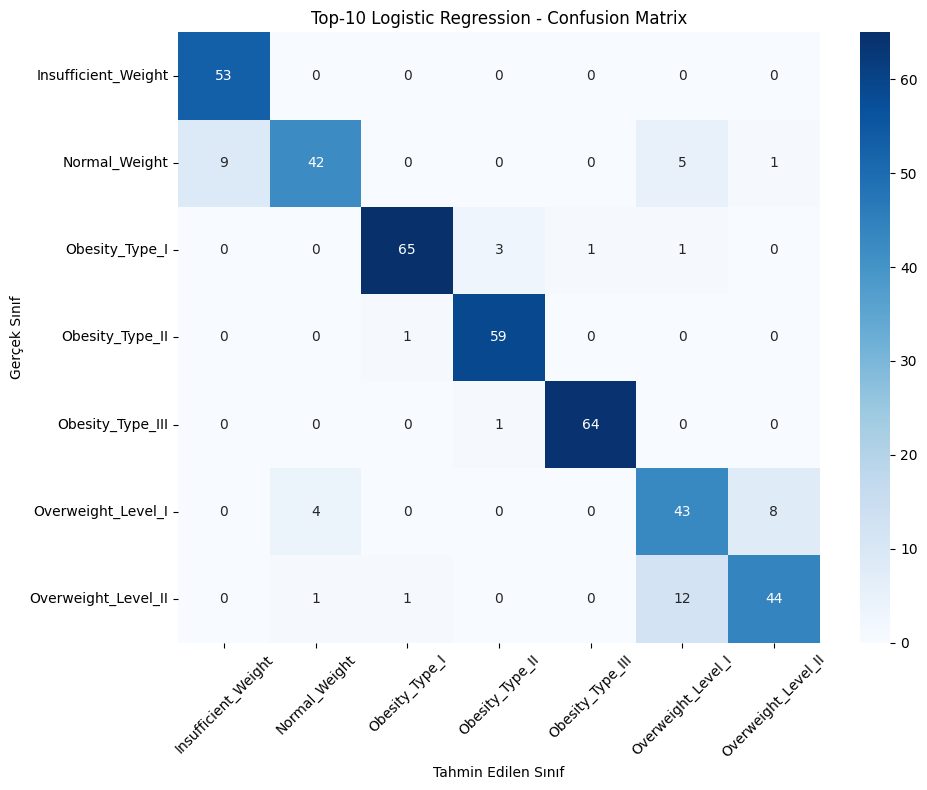

In [ ]:
labels_10 = sorted(y_top10.unique())
cm_logreg_10 = confusion_matrix(y_test_10, y_pred_logreg_10, labels=labels_10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_logreg_10, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_10, yticklabels=labels_10)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Top-10 Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/top10_logreg_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
rf_pipeline_10 = Pipeline([
    ('preprocessor', preprocessor_10),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print(rf_pipeline_10)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Weight', 'Age', 'FCVC',
                                                   'Height', 'NCP', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'CALC',
                                                   'family_history_with_overweight'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [ ]:
rf_pipeline_10.fit(X_train_10, y_train_10)
print("Top-10 Random Forest modeli eğitildi.")

Top-10 Random Forest modeli eğitildi.


In [ ]:
y_pred_rf_10 = rf_pipeline_10.predict(X_test_10)

print("İlk 10 tahmin (Top-10 Random Forest):")
print(y_pred_rf_10[:10])

İlk 10 tahmin (Top-10 Random Forest):
['Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_II' 'Obesity_Type_II']


In [ ]:
rf_accuracy_10 = accuracy_score(y_test_10, y_pred_rf_10)
rf_macro_f1_10 = f1_score(y_test_10, y_pred_rf_10, average='macro')
rf_weighted_f1_10 = f1_score(y_test_10, y_pred_rf_10, average='weighted')

print("Top-10 Random Forest Accuracy:", rf_accuracy_10)
print("Top-10 Random Forest Macro F1:", rf_macro_f1_10)
print("Top-10 Random Forest Weighted F1:", rf_weighted_f1_10)

Top-10 Random Forest Accuracy: 0.9401913875598086
Top-10 Random Forest Macro F1: 0.9381204009812552
Top-10 Random Forest Weighted F1: 0.9410500933641801


In [ ]:
print(classification_report(y_test_10, y_pred_rf_10))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.96      0.97        53
      Normal_Weight       0.80      0.91      0.85        57
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.85      0.85      0.85        55
Overweight_Level_II       0.96      0.88      0.92        58

           accuracy                           0.94       418
          macro avg       0.94      0.94      0.94       418
       weighted avg       0.94      0.94      0.94       418



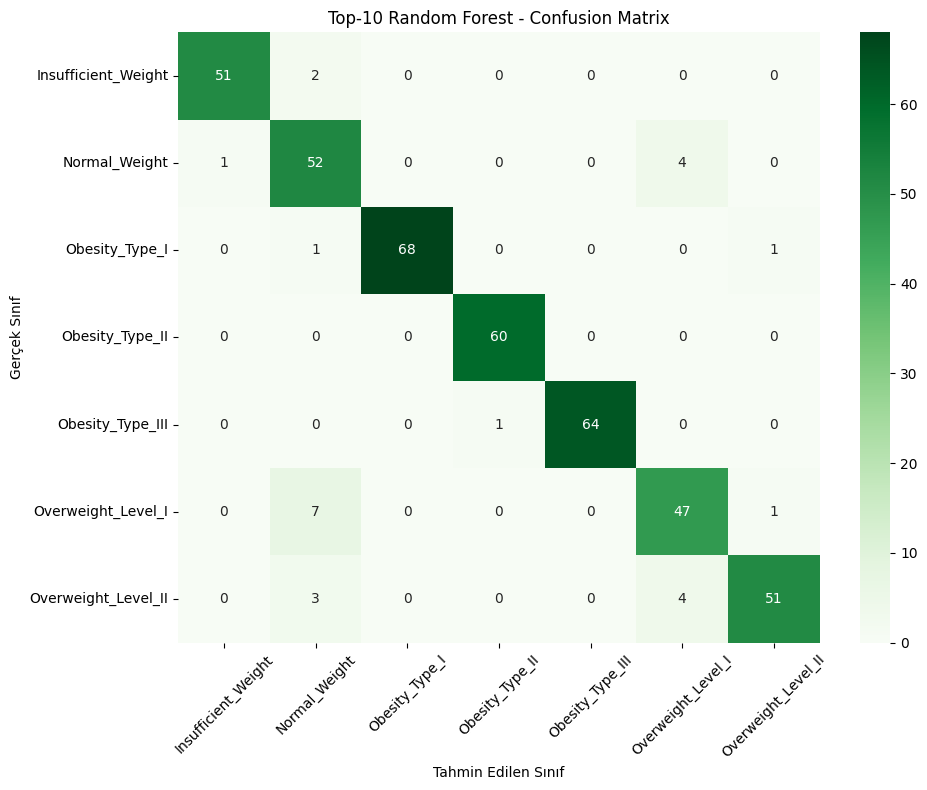

In [ ]:
cm_rf_10 = confusion_matrix(y_test_10, y_pred_rf_10, labels=labels_10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf_10, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_10, yticklabels=labels_10)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Top-10 Random Forest - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/top10_rf_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
final_comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression (16 özellik)',
        'Random Forest (16 özellik)',
        'Logistic Regression (10 özellik)',
        'Random Forest (10 özellik)'
    ],
    'Accuracy': [
        logreg_accuracy,
        rf_accuracy,
        logreg_accuracy_10,
        rf_accuracy_10
    ],
    'Macro F1': [
        logreg_macro_f1,
        rf_macro_f1,
        logreg_macro_f1_10,
        rf_macro_f1_10
    ],
    'Weighted F1': [
        logreg_weighted_f1,
        rf_weighted_f1,
        logreg_weighted_f1_10,
        rf_weighted_f1_10
    ]
})

final_comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (16 özellik),0.897129,0.892760,0.895354
1,Random Forest (16 özellik),0.944976,0.943956,0.946096
2,Logistic Regression (10 özellik),0.885167,0.879496,0.884289
3,Random Forest (10 özellik),0.940191,0.938120,0.941050


In [ ]:
final_comparison_df_rounded = final_comparison_df.copy()
final_comparison_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']] = (
    final_comparison_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']].round(4)
)

final_comparison_df_rounded

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (16 özellik),0.8971,0.8928,0.8954
1,Random Forest (16 özellik),0.9450,0.9440,0.9461
2,Logistic Regression (10 özellik),0.8852,0.8795,0.8843
3,Random Forest (10 özellik),0.9402,0.9381,0.9411


In [ ]:
final_comparison_df_rounded.to_csv(
    '/content/drive/MyDrive/Obesity_Quantum_Project/tables/final_classical_model_comparison.csv',
    index=False
)

print("Final klasik model karşılaştırma tablosu kaydedildi.")

Final klasik model karşılaştırma tablosu kaydedildi.


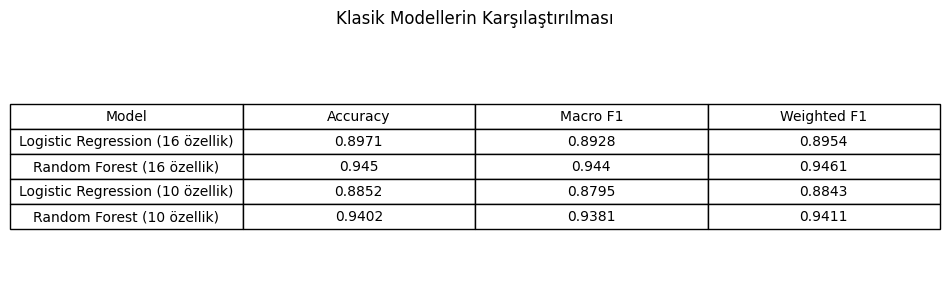

In [ ]:
plt.figure(figsize=(10, 3))
plt.axis('off')
table = plt.table(
    cellText=final_comparison_df_rounded.values,
    colLabels=final_comparison_df_rounded.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Klasik Modellerin Karşılaştırılması", pad=20)
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/figures/final_classical_model_comparison_table.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os

processed_data_dir = '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data'
os.makedirs(processed_data_dir, exist_ok=True)

print("processed_data klasörü hazır:", processed_data_dir)

processed_data klasörü hazır: /content/drive/MyDrive/Obesity_Quantum_Project/processed_data


In [ ]:
df.to_csv(f'{processed_data_dir}/obesity_cleaned_full.csv', index=False)
print("Temizlenmiş tam veri seti kaydedildi.")

Temizlenmiş tam veri seti kaydedildi.


In [ ]:
top10_df = df[top10_features + ['NObeyesdad']]
top10_df.to_csv(f'{processed_data_dir}/obesity_top10_dataset.csv', index=False)

print("Top-10 veri seti kaydedildi.")
print("Boyut:", top10_df.shape)

Top-10 veri seti kaydedildi.
Boyut: (2087, 11)


In [ ]:
train_16_df = X_train.copy()
train_16_df['NObeyesdad'] = y_train.values

test_16_df = X_test.copy()
test_16_df['NObeyesdad'] = y_test.values

train_16_df.to_csv(f'{processed_data_dir}/train_16_features.csv', index=False)
test_16_df.to_csv(f'{processed_data_dir}/test_16_features.csv', index=False)

print("16 özellikli train/test dosyaları kaydedildi.")
print("Train boyutu:", train_16_df.shape)
print("Test boyutu:", test_16_df.shape)

16 özellikli train/test dosyaları kaydedildi.
Train boyutu: (1669, 17)
Test boyutu: (418, 17)


In [ ]:
train_10_df = X_train_10.copy()
train_10_df['NObeyesdad'] = y_train_10.values

test_10_df = X_test_10.copy()
test_10_df['NObeyesdad'] = y_test_10.values

train_10_df.to_csv(f'{processed_data_dir}/train_10_features.csv', index=False)
test_10_df.to_csv(f'{processed_data_dir}/test_10_features.csv', index=False)

print("10 özellikli train/test dosyaları kaydedildi.")
print("Train boyutu:", train_10_df.shape)
print("Test boyutu:", test_10_df.shape)

10 özellikli train/test dosyaları kaydedildi.
Train boyutu: (1669, 11)
Test boyutu: (418, 11)


In [ ]:
top10_features_df = pd.DataFrame({'Top10_Features': top10_features})
top10_features_df.to_csv(f'{processed_data_dir}/top10_feature_list.csv', index=False)

print("Top-10 özellik listesi kaydedildi.")

Top-10 özellik listesi kaydedildi.


In [ ]:
os.listdir(processed_data_dir)

['obesity_cleaned_full.csv',
 'obesity_top10_dataset.csv',
 'train_16_features.csv',
 'test_16_features.csv',
 'train_10_features.csv',
 'test_10_features.csv',
 'top10_feature_list.csv']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier
print("XGBoost başarıyla yüklendi.")

XGBoost başarıyla yüklendi.


In [ ]:
project_dir = '/content/drive/MyDrive/Obesity_Quantum_Project'
processed_data_dir = f'{project_dir}/processed_data'
tables_dir = f'{project_dir}/tables'
figures_dir = f'{project_dir}/figures'

print("Project dir:", project_dir)
print("Processed data dir:", processed_data_dir)
print("Tables dir:", tables_dir)
print("Figures dir:", figures_dir)

Project dir: /content/drive/MyDrive/Obesity_Quantum_Project
Processed data dir: /content/drive/MyDrive/Obesity_Quantum_Project/processed_data
Tables dir: /content/drive/MyDrive/Obesity_Quantum_Project/tables
Figures dir: /content/drive/MyDrive/Obesity_Quantum_Project/figures


In [ ]:
print("processed_data içeriği:")
print(os.listdir(processed_data_dir))

print("\ntables içeriği:")
print(os.listdir(tables_dir))

print("\nfigures içeriği:")
print(os.listdir(figures_dir))

processed_data içeriği:
['obesity_cleaned_full.csv', 'obesity_top10_dataset.csv', 'train_16_features.csv', 'test_16_features.csv', 'train_10_features.csv', 'test_10_features.csv', 'top10_feature_list.csv']

tables içeriği:
['model_comparison_initial.csv', 'model_comparison_with_f1.csv', 'model_comparison_with_f1_rounded.csv', 'original_feature_importance.csv', 'final_classical_model_comparison.csv']

figures içeriği:
['class_distribution.png', 'logreg_confusion_matrix.png', 'rf_feature_importance_top15.png', 'rf_original_feature_importance_top10.png', 'top10_logreg_confusion_matrix.png', 'top10_rf_confusion_matrix.png', 'final_classical_model_comparison_table.png']


In [ ]:
df = pd.read_csv(f'{processed_data_dir}/obesity_cleaned_full.csv')
top10_df = pd.read_csv(f'{processed_data_dir}/obesity_top10_dataset.csv')

print("Tam veri boyutu:", df.shape)
print("Top10 veri boyutu:", top10_df.shape)

Tam veri boyutu: (2087, 17)
Top10 veri boyutu: (2087, 11)


In [ ]:
train_16_df = pd.read_csv(f'{processed_data_dir}/train_16_features.csv')
test_16_df = pd.read_csv(f'{processed_data_dir}/test_16_features.csv')

train_10_df = pd.read_csv(f'{processed_data_dir}/train_10_features.csv')
test_10_df = pd.read_csv(f'{processed_data_dir}/test_10_features.csv')

print("train_16:", train_16_df.shape)
print("test_16:", test_16_df.shape)
print("train_10:", train_10_df.shape)
print("test_10:", test_10_df.shape)

train_16: (1669, 17)
test_16: (418, 17)
train_10: (1669, 11)
test_10: (418, 11)


In [ ]:
target_col = 'NObeyesdad'

X_train = train_16_df.drop(columns=[target_col])
y_train = train_16_df[target_col]

X_test = test_16_df.drop(columns=[target_col])
y_test = test_16_df[target_col]

X_train_10 = train_10_df.drop(columns=[target_col])
y_train_10 = train_10_df[target_col]

X_test_10 = test_10_df.drop(columns=[target_col])
y_test_10 = test_10_df[target_col]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train_10:", X_train_10.shape)
print("X_test_10:", X_test_10.shape)

X_train: (1669, 16)
X_test: (418, 16)
X_train_10: (1669, 10)
X_test_10: (418, 10)


In [ ]:
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

top10_features = [
    'Weight',
    'Age',
    'FCVC',
    'Height',
    'Gender',
    'NCP',
    'CALC',
    'FAF',
    'TUE',
    'family_history_with_overweight'
]

numerical_features_10 = ['Weight', 'Age', 'FCVC', 'Height', 'NCP', 'FAF', 'TUE']
categorical_features_10 = ['Gender', 'CALC', 'family_history_with_overweight']

print("16 özellikli sayısal:", numerical_features)
print("16 özellikli kategorik:", categorical_features)
print("10 özellikli sayısal:", numerical_features_10)
print("10 özellikli kategorik:", categorical_features_10)

16 özellikli sayısal: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
16 özellikli kategorik: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
10 özellikli sayısal: ['Weight', 'Age', 'FCVC', 'Height', 'NCP', 'FAF', 'TUE']
10 özellikli kategorik: ['Gender', 'CALC', 'family_history_with_overweight']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor_10 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_10),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_10)
    ]
)

print("16 özellikli preprocessor hazır.")
print("10 özellikli preprocessor hazır.")

16 özellikli preprocessor hazır.
10 özellikli preprocessor hazır.


In [ ]:
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_macro_f1 = f1_score(y_test, y_pred_logreg, average='macro')
logreg_weighted_f1 = f1_score(y_test, y_pred_logreg, average='weighted')

print("Logistic Regression (16 özellik) hazır.")
print("Accuracy:", logreg_accuracy)
print("Macro F1:", logreg_macro_f1)
print("Weighted F1:", logreg_weighted_f1)

Logistic Regression (16 özellik) hazır.
Accuracy: 0.8971291866028708
Macro F1: 0.8927601155481121
Weighted F1: 0.8953540299877092


In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest (16 özellik) hazır.")
print("Accuracy:", rf_accuracy)
print("Macro F1:", rf_macro_f1)
print("Weighted F1:", rf_weighted_f1)

Random Forest (16 özellik) hazır.
Accuracy: 0.9449760765550239
Macro F1: 0.9439555001638159
Weighted F1: 0.946095619869087


In [ ]:
logreg_pipeline_10 = Pipeline([
    ('preprocessor', preprocessor_10),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline_10.fit(X_train_10, y_train_10)
y_pred_logreg_10 = logreg_pipeline_10.predict(X_test_10)

logreg_accuracy_10 = accuracy_score(y_test_10, y_pred_logreg_10)
logreg_macro_f1_10 = f1_score(y_test_10, y_pred_logreg_10, average='macro')
logreg_weighted_f1_10 = f1_score(y_test_10, y_pred_logreg_10, average='weighted')

print("Logistic Regression (10 özellik) hazır.")
print("Accuracy:", logreg_accuracy_10)
print("Macro F1:", logreg_macro_f1_10)
print("Weighted F1:", logreg_weighted_f1_10)

Logistic Regression (10 özellik) hazır.
Accuracy: 0.8851674641148325
Macro F1: 0.8794962326950116
Weighted F1: 0.8842890257809621


In [ ]:
rf_pipeline_10 = Pipeline([
    ('preprocessor', preprocessor_10),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_10.fit(X_train_10, y_train_10)
y_pred_rf_10 = rf_pipeline_10.predict(X_test_10)

rf_accuracy_10 = accuracy_score(y_test_10, y_pred_rf_10)
rf_macro_f1_10 = f1_score(y_test_10, y_pred_rf_10, average='macro')
rf_weighted_f1_10 = f1_score(y_test_10, y_pred_rf_10, average='weighted')

print("Random Forest (10 özellik) hazır.")
print("Accuracy:", rf_accuracy_10)
print("Macro F1:", rf_macro_f1_10)
print("Weighted F1:", rf_weighted_f1_10)

Random Forest (10 özellik) hazır.
Accuracy: 0.9401913875598086
Macro F1: 0.9381204009812552
Weighted F1: 0.9410500933641801


In [ ]:
recheck_df = pd.DataFrame({
    'Model': [
        'Logistic Regression (16 özellik)',
        'Random Forest (16 özellik)',
        'Logistic Regression (10 özellik)',
        'Random Forest (10 özellik)'
    ],
    'Accuracy': [
        logreg_accuracy,
        rf_accuracy,
        logreg_accuracy_10,
        rf_accuracy_10
    ],
    'Macro F1': [
        logreg_macro_f1,
        rf_macro_f1,
        logreg_macro_f1_10,
        rf_macro_f1_10
    ],
    'Weighted F1': [
        logreg_weighted_f1,
        rf_weighted_f1,
        logreg_weighted_f1_10,
        rf_weighted_f1_10
    ]
})

recheck_df.round(4)

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (16 özellik),0.8971,0.8928,0.8954
1,Random Forest (16 özellik),0.9450,0.9440,0.9461
2,Logistic Regression (10 özellik),0.8852,0.8795,0.8843
3,Random Forest (10 özellik),0.9402,0.9381,0.9411


In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder_16 = LabelEncoder()

y_train_encoded = target_encoder_16.fit_transform(y_train)
y_test_encoded = target_encoder_16.transform(y_test)

print("Sınıf sıralaması:", list(target_encoder_16.classes_))
print("İlk 10 encoded y_train:", y_train_encoded[:10])

Sınıf sıralaması: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
İlk 10 encoded y_train: [3 3 6 0 5 6 1 3 3 4]


In [ ]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=7,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

print(xgb_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=Non...
                               feature_types=None, feature_weights=

In [ ]:
xgb_pipeline.fit(X_train, y_train_encoded)
print("XGBoost (16 özellik) modeli eğitildi.")

XGBoost (16 özellik) modeli eğitildi.


In [ ]:
y_pred_xgb_encoded = xgb_pipeline.predict(X_test)
y_pred_xgb = target_encoder_16.inverse_transform(y_pred_xgb_encoded)

print("İlk 10 XGBoost tahmini:")
print(y_pred_xgb[:10])

İlk 10 XGBoost tahmini:
['Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_II' 'Obesity_Type_II']


In [ ]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_macro_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_weighted_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print("XGBoost (16 özellik) Accuracy:", xgb_accuracy)
print("XGBoost (16 özellik) Macro F1:", xgb_macro_f1)
print("XGBoost (16 özellik) Weighted F1:", xgb_weighted_f1)

XGBoost (16 özellik) Accuracy: 0.9688995215311005
XGBoost (16 özellik) Macro F1: 0.9678438933206861
XGBoost (16 özellik) Weighted F1: 0.9687893828318498


In [ ]:
print(classification_report(y_test, y_pred_xgb))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.93      0.93      0.93        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.91      0.93        55
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



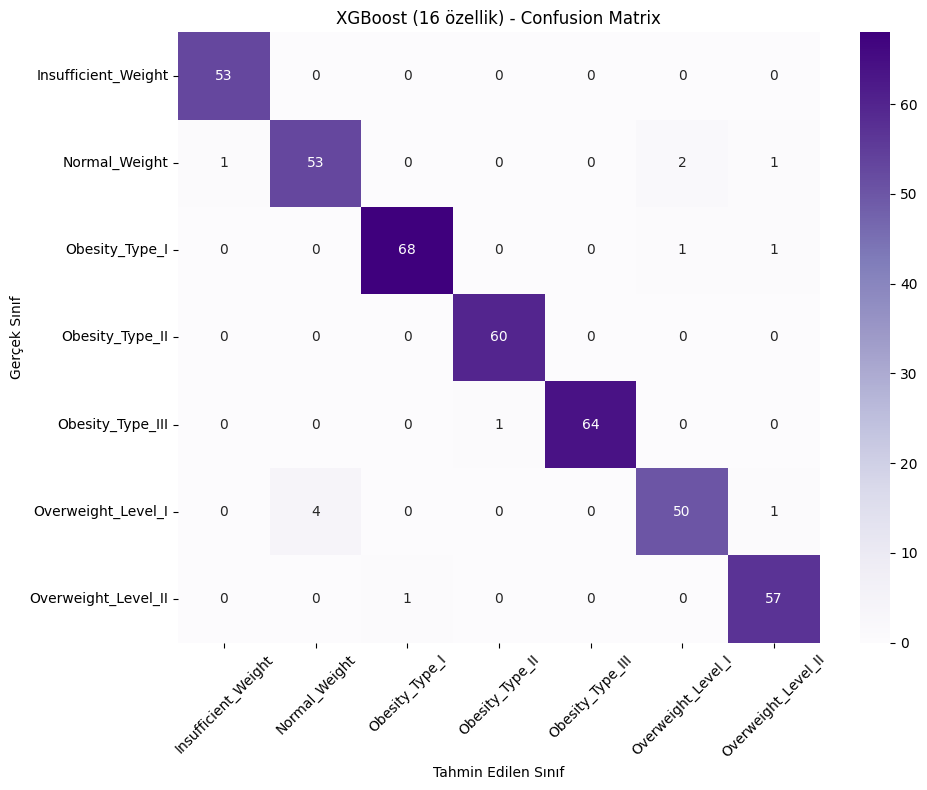

In [ ]:
labels = sorted(y_train.unique())

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("XGBoost (16 özellik) - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{figures_dir}/xgb_16_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
target_encoder_10 = LabelEncoder()

y_train_10_encoded = target_encoder_10.fit_transform(y_train_10)
y_test_10_encoded = target_encoder_10.transform(y_test_10)

print("Top-10 sınıf sıralaması:", list(target_encoder_10.classes_))
print("İlk 10 encoded y_train_10:", y_train_10_encoded[:10])

Top-10 sınıf sıralaması: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
İlk 10 encoded y_train_10: [3 3 6 0 5 6 1 3 3 4]


In [ ]:
xgb_pipeline_10 = Pipeline([
    ('preprocessor', preprocessor_10),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=7,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

print(xgb_pipeline_10)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Weight', 'Age', 'FCVC',
                                                   'Height', 'NCP', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'CALC',
                                                   'family_history_with_overweight'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=No...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
      

In [ ]:
xgb_pipeline_10.fit(X_train_10, y_train_10_encoded)
print("XGBoost (10 özellik) modeli eğitildi.")

XGBoost (10 özellik) modeli eğitildi.


In [ ]:
y_pred_xgb_10_encoded = xgb_pipeline_10.predict(X_test_10)
y_pred_xgb_10 = target_encoder_10.inverse_transform(y_pred_xgb_10_encoded)

print("İlk 10 XGBoost (10 özellik) tahmini:")
print(y_pred_xgb_10[:10])

İlk 10 XGBoost (10 özellik) tahmini:
['Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_III'
 'Overweight_Level_I' 'Obesity_Type_I' 'Obesity_Type_I' 'Obesity_Type_I'
 'Overweight_Level_II' 'Obesity_Type_I' 'Obesity_Type_II']


In [ ]:
xgb_accuracy_10 = accuracy_score(y_test_10, y_pred_xgb_10)
xgb_macro_f1_10 = f1_score(y_test_10, y_pred_xgb_10, average='macro')
xgb_weighted_f1_10 = f1_score(y_test_10, y_pred_xgb_10, average='weighted')

print("XGBoost (10 özellik) Accuracy:", xgb_accuracy_10)
print("XGBoost (10 özellik) Macro F1:", xgb_macro_f1_10)
print("XGBoost (10 özellik) Weighted F1:", xgb_weighted_f1_10)

XGBoost (10 özellik) Accuracy: 0.9688995215311005
XGBoost (10 özellik) Macro F1: 0.9680748137912182
XGBoost (10 özellik) Weighted F1: 0.9688259032145777


In [ ]:
print(classification_report(y_test_10, y_pred_xgb_10))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.96      0.91      0.94        57
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.93      0.93        55
Overweight_Level_II       0.93      0.98      0.96        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



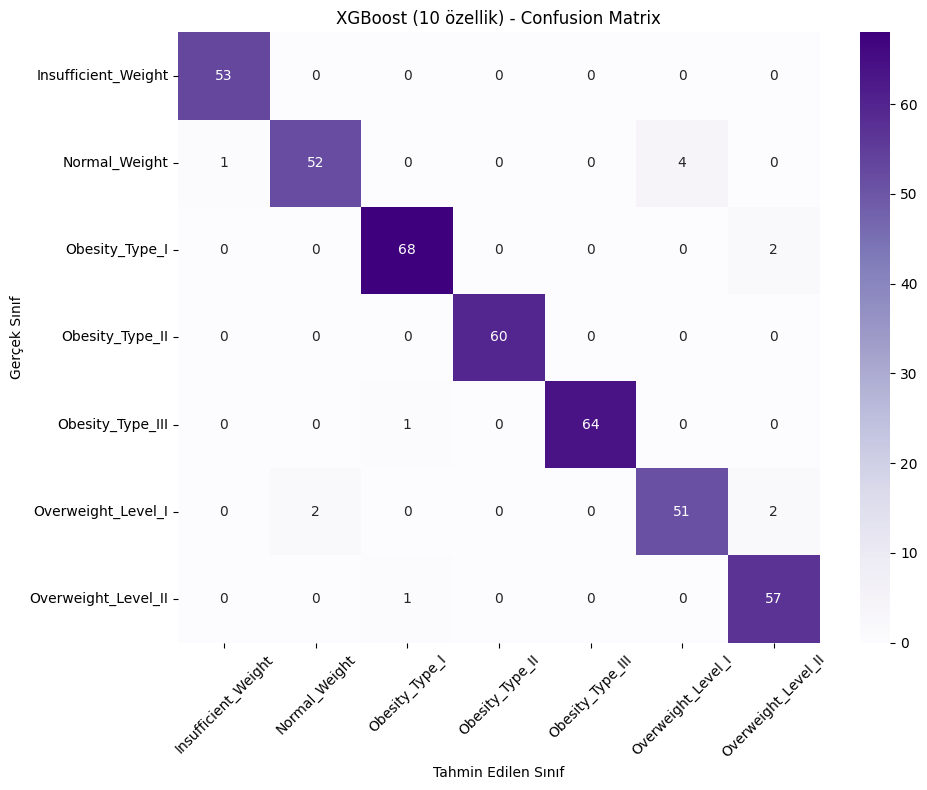

In [ ]:
labels_10 = sorted(y_train_10.unique())

cm_xgb_10 = confusion_matrix(y_test_10, y_pred_xgb_10, labels=labels_10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb_10, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_10, yticklabels=labels_10)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("XGBoost (10 özellik) - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{figures_dir}/xgb_10_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
final_classical_df = pd.DataFrame({
    'Model': [
        'Logistic Regression (16 özellik)',
        'Random Forest (16 özellik)',
        'XGBoost (16 özellik)',
        'Logistic Regression (10 özellik)',
        'Random Forest (10 özellik)',
        'XGBoost (10 özellik)'
    ],
    'Accuracy': [
        logreg_accuracy,
        rf_accuracy,
        xgb_accuracy,
        logreg_accuracy_10,
        rf_accuracy_10,
        xgb_accuracy_10
    ],
    'Macro F1': [
        logreg_macro_f1,
        rf_macro_f1,
        xgb_macro_f1,
        logreg_macro_f1_10,
        rf_macro_f1_10,
        xgb_macro_f1_10
    ],
    'Weighted F1': [
        logreg_weighted_f1,
        rf_weighted_f1,
        xgb_weighted_f1,
        logreg_weighted_f1_10,
        rf_weighted_f1_10,
        xgb_weighted_f1_10
    ]
})

final_classical_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (16 özellik),0.897129,0.892760,0.895354
1,Random Forest (16 özellik),0.944976,0.943956,0.946096
2,XGBoost (16 özellik),0.968900,0.967844,0.968789
3,Logistic Regression (10 özellik),0.885167,0.879496,0.884289
4,Random Forest (10 özellik),0.940191,0.938120,0.941050
5,XGBoost (10 özellik),0.968900,0.968075,0.968826


In [ ]:
final_classical_df_rounded = final_classical_df.copy()
final_classical_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']] = (
    final_classical_df_rounded[['Accuracy', 'Macro F1', 'Weighted F1']].round(4)
)

final_classical_df_rounded

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (16 özellik),0.8971,0.8928,0.8954
1,Random Forest (16 özellik),0.9450,0.9440,0.9461
2,XGBoost (16 özellik),0.9689,0.9678,0.9688
3,Logistic Regression (10 özellik),0.8852,0.8795,0.8843
4,Random Forest (10 özellik),0.9402,0.9381,0.9411
5,XGBoost (10 özellik),0.9689,0.9681,0.9688


In [ ]:
final_classical_df_rounded.to_csv(
    f'{tables_dir}/final_classical_model_comparison_with_xgb.csv',
    index=False
)

print("XGBoost eklenmiş final klasik karşılaştırma tablosu kaydedildi.")

XGBoost eklenmiş final klasik karşılaştırma tablosu kaydedildi.


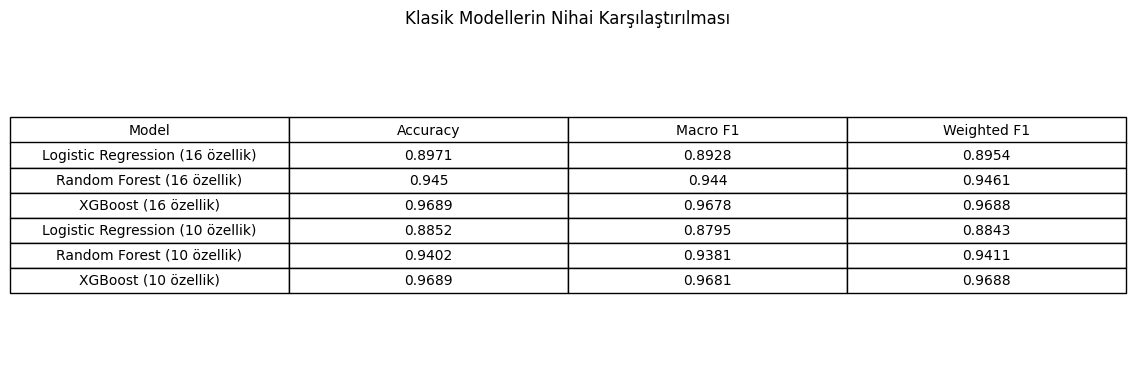

In [ ]:
plt.figure(figsize=(12, 4))
plt.axis('off')
table = plt.table(
    cellText=final_classical_df_rounded.values,
    colLabels=final_classical_df_rounded.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Klasik Modellerin Nihai Karşılaştırılması", pad=20)
plt.savefig(f'{figures_dir}/final_classical_model_comparison_with_xgb.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
xgb_model = xgb_pipeline.named_steps['model']
xgb_preprocessor = xgb_pipeline.named_steps['preprocessor']

xgb_feature_names = xgb_preprocessor.get_feature_names_out()
xgb_importances = xgb_model.feature_importances_

print("Toplam dönüştürülmüş özellik sayısı:", len(xgb_feature_names))
print("Toplam importance sayısı:", len(xgb_importances))

Toplam dönüştürülmüş özellik sayısı: 31
Toplam importance sayısı: 31


In [ ]:
xgb_feat_imp_df = pd.DataFrame({
    'Özellik': xgb_feature_names,
    'Önem': xgb_importances
}).sort_values(by='Önem', ascending=False)

xgb_feat_imp_df.head(20)

,Özellik,Önem
8,cat__Gender_Female,0.182638
2,num__Weight,0.094454
9,cat__Gender_Male,0.087658
3,num__FCVC,0.071430
17,cat__CAEC_no,0.068298
12,cat__FAVC_no,0.042420
25,cat__CALC_no,0.039421
21,cat__SCC_yes,0.035057
1,num__Height,0.029283
30,cat__MTRANS_Walking,0.027723


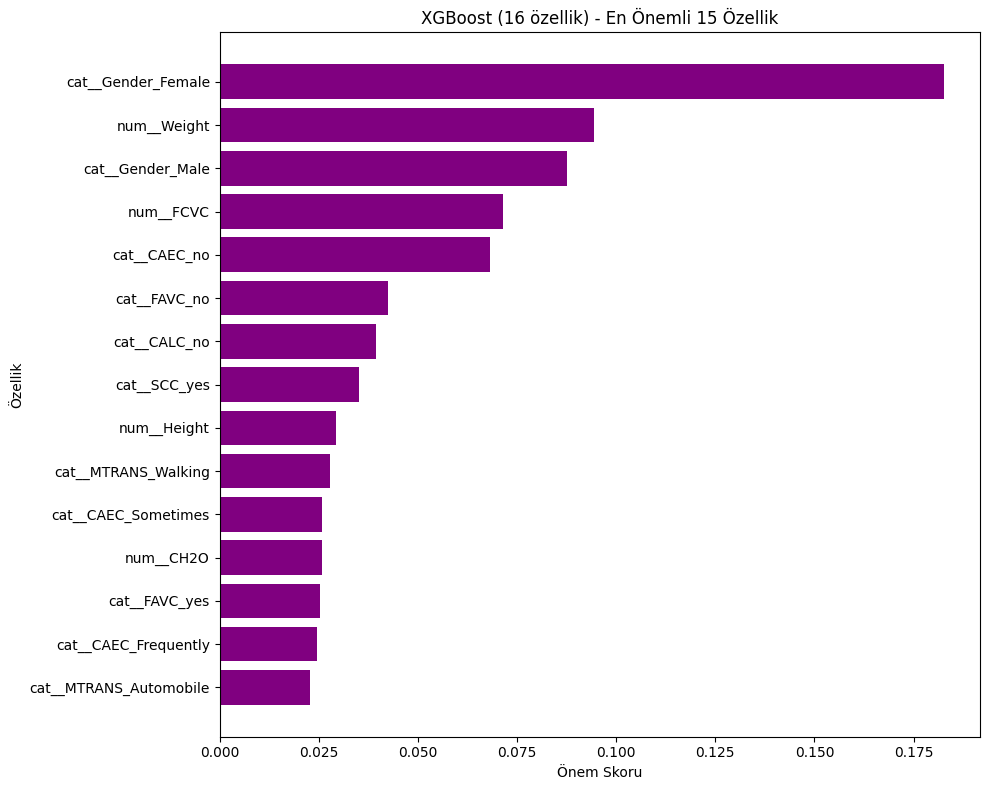

In [ ]:
plt.figure(figsize=(10, 8))
top_n = 15
top_xgb_features = xgb_feat_imp_df.head(top_n).sort_values(by='Önem', ascending=True)

plt.barh(top_xgb_features['Özellik'], top_xgb_features['Önem'], color='purple')
plt.xlabel("Önem Skoru")
plt.ylabel("Özellik")
plt.title("XGBoost (16 özellik) - En Önemli 15 Özellik")
plt.tight_layout()
plt.savefig(f'{figures_dir}/xgb_16_feature_importance_top15.png', dpi=300)
plt.show()

In [ ]:
xgb_feat_imp_df.to_csv(f'{tables_dir}/xgb_16_feature_importance.csv', index=False)
print("XGBoost (16 özellik) feature importance tablosu kaydedildi.")

XGBoost (16 özellik) feature importance tablosu kaydedildi.


In [ ]:
xgb_original_feature_importance = {}

for feat_name, importance in zip(xgb_feature_names, xgb_importances):
    if feat_name.startswith('num__'):
        original_name = feat_name.replace('num__', '')

    elif feat_name.startswith('cat__'):
        cat_feature = feat_name.replace('cat__', '')

        matched_feature = None
        for col in categorical_features:
            if cat_feature.startswith(col + '_') or cat_feature == col:
                matched_feature = col
                break

        original_name = matched_feature if matched_feature is not None else cat_feature

    else:
        original_name = feat_name

    if original_name in xgb_original_feature_importance:
        xgb_original_feature_importance[original_name] += importance
    else:
        xgb_original_feature_importance[original_name] = importance

xgb_original_feat_imp_df = pd.DataFrame({
    'Özellik': list(xgb_original_feature_importance.keys()),
    'Toplam_Önem': list(xgb_original_feature_importance.values())
}).sort_values(by='Toplam_Önem', ascending=False)

xgb_original_feat_imp_df

,Özellik,Toplam_Önem
8,Gender,0.270296
11,CAEC,0.125423
2,Weight,0.094454
14,CALC,0.071506
3,FCVC,0.071430
10,FAVC,0.067779
15,MTRANS,0.056237
13,SCC,0.048679
9,family_history_with_overweight,0.034243
1,Height,0.029283


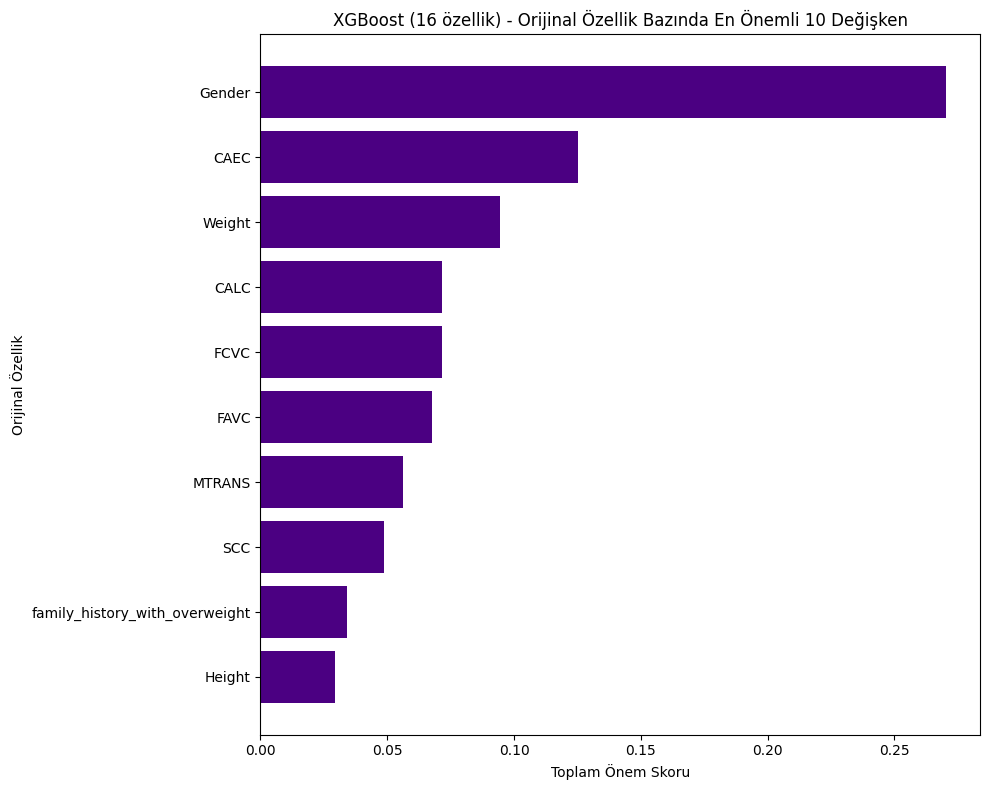

In [ ]:
plt.figure(figsize=(10, 8))
top_n = 10
top_xgb_original = xgb_original_feat_imp_df.head(top_n).sort_values(by='Toplam_Önem', ascending=True)

plt.barh(top_xgb_original['Özellik'], top_xgb_original['Toplam_Önem'], color='indigo')
plt.xlabel("Toplam Önem Skoru")
plt.ylabel("Orijinal Özellik")
plt.title("XGBoost (16 özellik) - Orijinal Özellik Bazında En Önemli 10 Değişken")
plt.tight_layout()
plt.savefig(f'{figures_dir}/xgb_16_original_feature_importance_top10.png', dpi=300)
plt.show()

In [ ]:
xgb_original_feat_imp_df.to_csv(f'{tables_dir}/xgb_16_original_feature_importance.csv', index=False)
print("XGBoost (16 özellik) orijinal feature importance tablosu kaydedildi.")

XGBoost (16 özellik) orijinal feature importance tablosu kaydedildi.


In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
perm_result_xgb_10 = permutation_importance(
    xgb_pipeline_10,
    X_test_10,
    y_test_10_encoded,
    n_repeats=10,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

print("Permutation importance hesaplandı.")

Permutation importance hesaplandı.


In [ ]:
perm_importance_xgb_10_df = pd.DataFrame({
    'Özellik': X_test_10.columns,
    'Ortalama_Önem': perm_result_xgb_10.importances_mean,
    'Std': perm_result_xgb_10.importances_std
}).sort_values(by='Ortalama_Önem', ascending=False)

perm_importance_xgb_10_df

,Özellik,Ortalama_Önem,Std
0,Weight,0.741148,0.015047
3,Height,0.266746,0.013670
4,Gender,0.141388,0.011983
1,Age,0.020335,0.005884
8,TUE,0.011244,0.003036
2,FCVC,0.011005,0.002664
5,NCP,0.010048,0.003675
7,FAF,0.009569,0.002831
6,CALC,0.006938,0.003775
9,family_history_with_overweight,0.004067,0.003036


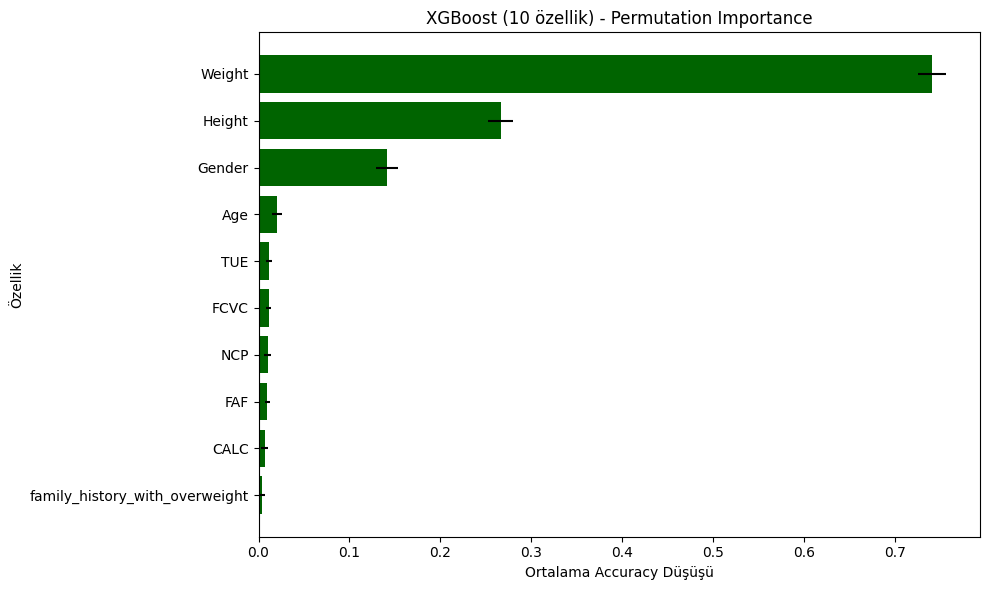

In [ ]:
plt.figure(figsize=(10, 6))
top_perm = perm_importance_xgb_10_df.sort_values(by='Ortalama_Önem', ascending=True)

plt.barh(top_perm['Özellik'], top_perm['Ortalama_Önem'], xerr=top_perm['Std'], color='darkgreen')
plt.xlabel("Ortalama Accuracy Düşüşü")
plt.ylabel("Özellik")
plt.title("XGBoost (10 özellik) - Permutation Importance")
plt.tight_layout()
plt.savefig(f'{figures_dir}/xgb_10_permutation_importance.png', dpi=300)
plt.show()

In [ ]:
perm_importance_xgb_10_df.to_csv(f'{tables_dir}/xgb_10_permutation_importance.csv', index=False)
print("XGBoost (10 özellik) permutation importance tablosu kaydedildi.")

XGBoost (10 özellik) permutation importance tablosu kaydedildi.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
rf_cv_accuracy = cross_val_score(
    rf_pipeline_10,
    X_train_10,
    y_train_10,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("Random Forest (10) CV Accuracy skorları:", rf_cv_accuracy)
print("Ortalama CV Accuracy:", rf_cv_accuracy.mean())
print("Std CV Accuracy:", rf_cv_accuracy.std())

Random Forest (10) CV Accuracy skorları: [0.93712575 0.95508982 0.92215569 0.94311377 0.93993994]
Ortalama CV Accuracy: 0.9394849939760122
Std CV Accuracy: 0.010609019547165416


In [ ]:
rf_cv_f1 = cross_val_score(
    rf_pipeline_10,
    X_train_10,
    y_train_10,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("Random Forest (10) CV Macro F1 skorları:", rf_cv_f1)
print("Ortalama CV Macro F1:", rf_cv_f1.mean())
print("Std CV Macro F1:", rf_cv_f1.std())

Random Forest (10) CV Macro F1 skorları: [0.93360354 0.95365747 0.92001291 0.94160125 0.93772049]
Ortalama CV Macro F1: 0.9373191303118832
Std CV Macro F1: 0.010943031342358907


In [ ]:
xgb_cv_accuracy = cross_val_score(
    xgb_pipeline_10,
    X_train_10,
    y_train_10_encoded,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("XGBoost (10) CV Accuracy skorları:", xgb_cv_accuracy)
print("Ortalama CV Accuracy:", xgb_cv_accuracy.mean())
print("Std CV Accuracy:", xgb_cv_accuracy.std())

XGBoost (10) CV Accuracy skorları: [0.95808383 0.97305389 0.95209581 0.95808383 0.97897898]
Ortalama CV Accuracy: 0.9640592688496881
Std CV Accuracy: 0.010178772708365182


In [ ]:
xgb_cv_f1 = cross_val_score(
    xgb_pipeline_10,
    X_train_10,
    y_train_10_encoded,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("XGBoost (10) CV Macro F1 skorları:", xgb_cv_f1)
print("Ortalama CV Macro F1:", xgb_cv_f1.mean())
print("Std CV Macro F1:", xgb_cv_f1.std())

XGBoost (10) CV Macro F1 skorları: [0.9555879  0.97171242 0.95136815 0.95800426 0.97751848]
Ortalama CV Macro F1: 0.9628382417387902
Std CV Macro F1: 0.010017569209271682


In [ ]:
cv_summary_df = pd.DataFrame({
    'Model': [
        'Random Forest (10 özellik)',
        'XGBoost (10 özellik)'
    ],
    'CV Accuracy Mean': [
        rf_cv_accuracy.mean(),
        xgb_cv_accuracy.mean()
    ],
    'CV Accuracy Std': [
        rf_cv_accuracy.std(),
        xgb_cv_accuracy.std()
    ],
    'CV Macro F1 Mean': [
        rf_cv_f1.mean(),
        xgb_cv_f1.mean()
    ],
    'CV Macro F1 Std': [
        rf_cv_f1.std(),
        xgb_cv_f1.std()
    ]
})

cv_summary_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std
0,Random Forest (10 özellik),0.939485,0.010609,0.937319,0.010943
1,XGBoost (10 özellik),0.964059,0.010179,0.962838,0.010018


In [ ]:
cv_summary_df_rounded = cv_summary_df.copy()
cv_summary_df_rounded.iloc[:, 1:] = cv_summary_df_rounded.iloc[:, 1:].round(4)

cv_summary_df_rounded

,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std
0,Random Forest (10 özellik),0.9395,0.0106,0.9373,0.0109
1,XGBoost (10 özellik),0.9641,0.0102,0.9628,0.0100


In [ ]:
cv_summary_df_rounded.to_csv(f'{tables_dir}/cv_summary_top_models.csv', index=False)
print("CV özet tablosu kaydedildi.")

CV özet tablosu kaydedildi.


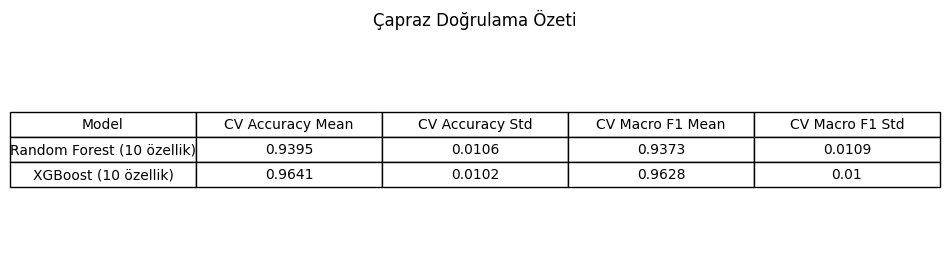

In [ ]:
plt.figure(figsize=(10, 2.5))
plt.axis('off')
table = plt.table(
    cellText=cv_summary_df_rounded.values,
    colLabels=cv_summary_df_rounded.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Çapraz Doğrulama Özeti", pad=20)
plt.savefig(f'{figures_dir}/cv_summary_top_models.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import sklearn
import xgboost
import sys

versions_df = pd.DataFrame({
    'Paket': ['Python', 'pandas', 'numpy', 'scikit-learn', 'xgboost'],
    'Versiyon': [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        xgboost.__version__
    ]
})

versions_df

,Paket,Versiyon
0,Python,3.12.13
1,pandas,2.2.2
2,numpy,2.0.2
3,scikit-learn,1.6.1
4,xgboost,3.2.0


In [ ]:
versions_df.to_csv(f'{tables_dir}/package_versions.csv', index=False)
print("Paket sürümleri kaydedildi.")

Paket sürümleri kaydedildi.


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

file_path = "/content/drive/MyDrive/Obesity_Quantum_Project/processed_data/obesity_cleaned_full.csv"
df_clean = pd.read_csv(file_path)

df_clean.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data/obesity_cleaned_full.csv'